# Compare P3D with and without HCD Contamination

Attempt to reproduce something similar to the bottom panel of Fig B1 in McQuinn & White (2011, https://arxiv.org/abs/1102.1752)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

In [3]:
from lace.cosmo import cosmology
from cupix.likelihood.theory import Theory

In [4]:
# default cosmology for now
cosmo = cosmology.Cosmology()
vars(cosmo)

{'input_cosmo_label': None,
 'input_cosmo_params_dict': None,
 'CAMBparams': class: <CAMBparams>
 WantCls = True
 WantTransfer = False
 WantScalars = True
 WantTensors = False
 WantVectors = False
 WantDerivedParameters = True
 Want_cl_2D_array = True
 Want_CMB = True
 Want_CMB_lensing = True
 DoLensing = True
 NonLinear = NonLinear_none
 Transfer: <TransferParams>
   high_precision = False
   accurate_massive_neutrinos = False
   kmax = 0.9
   k_per_logint = 0
   PK_num_redshifts = 1
   PK_redshifts = [0.0]
 want_zstar = False
 want_zdrag = False
 min_l = 2
 max_l = 2500
 max_l_tensor = 600
 max_eta_k = 5000.0
 max_eta_k_tensor = 1200.0
 ombh2 = 0.02242
 omch2 = 0.11933
 omk = 0.0
 omnuh2 = 0.0
 H0 = 67.66
 TCMB = 2.7255
 YHe = 0.24590381304853062
 num_nu_massless = 3.046
 num_nu_massive = 0
 nu_mass_eigenstates = 0
 share_delta_neff = False
 nu_mass_degeneracies = []
 nu_mass_fractions = []
 nu_mass_numbers = []
 InitPower: <InitialPowerLaw>
   tensor_parameterization = tensor_param_

In [5]:
# redshift and bias / beta from that paper
z = 2.5
bias = -0.18
beta = 1.0
# close to value used in McQuinn & White, although in there this is kpar smoothing only
kp_Mpc = 0.08 * cosmo.get_dkms_dMpc(z)
print('k_p = {:.3f} 1/Mpc'.format(kp_Mpc))
# HCD model (L_H
b_H = -0.036
beta_H = 0.5
L_H = 7.0  / cosmo.get_h()
print('L_H = {:.3f} Mpc'.format(L_H))
config = dict(bias=bias, beta=beta, q1=0, q2=0, kp_Mpc=kp_Mpc,
              include_hcd=True, b_H=b_H, beta_H=beta_H, L_H=L_H,
              verbose=True)

k_p = 5.782 1/Mpc
L_H = 10.346 Mpc


In [6]:
theory = Theory(z, fid_cosmo=cosmo, config=config)

LyaModel::setup_from_config
LyaModel::get_default_lya_params
initial values {'bias': -0.13827178966115714, 'beta': 1.4178048358716402, 'q1': 0.33369611625260176, 'kvav': 0.5709771352811059, 'av': 0.4055657283063022, 'bv': 1.6647876909430759, 'kp': 12.514370161342079, 'q2': 0.2533086488252884}
final values {'bias': -0.18, 'beta': 1.0, 'q1': 0, 'av': 0.4055657283063022, 'bv': 1.6647876909430759, 'q2': 0, 'kp_Mpc': 5.782362549994954, 'kv_Mpc': 0.25112897347553936}
ContaminantsModel::setup_from_config


In [7]:
def compare_p3d(mu, relative=False):
    k = np.logspace(-3, 1, 1000)
    p3d_lya = theory.get_p3d_lya_Mpc(k=k, mu=mu)
    p3d_lya_hcd = theory.get_p3d_lya_hcd_Mpc(k=k, mu=mu)
    if relative:
        plt.semilogx(k, p3d_lya_hcd / p3d_lya - 1.0)
        plt.ylabel('relative P3D contamination')
        plt.ylim(-0.5, 0.5)
    else:
        plt.loglog(k, p3d_lya, label='Lya only')
        plt.loglog(k, p3d_lya_hcd, label='Lya + HCD')
        p3d_max = np.max(p3d_lya_hcd)
        plt.ylim(0.001*p3d_max, 2*p3d_max)
        plt.ylabel('P3D [Mpc^3]')
        plt.legend()
    plt.xlabel('k [1/Mpc]')
    plt.title(r'$\mu =$ {:.2f}'.format(mu))

recycle transfer function
recycle transfer function


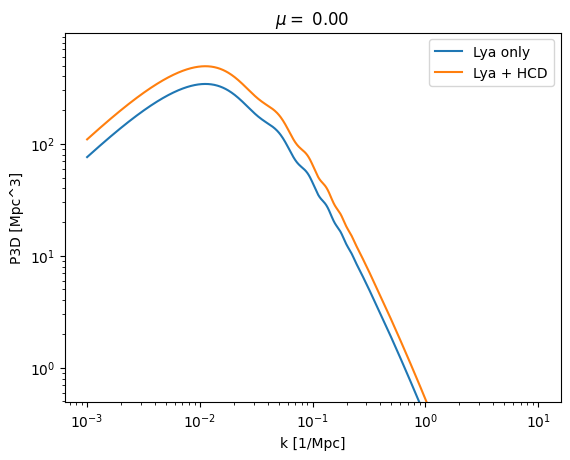

In [10]:
compare_p3d(mu=0.0, relative=False)

recycle transfer function
recycle transfer function


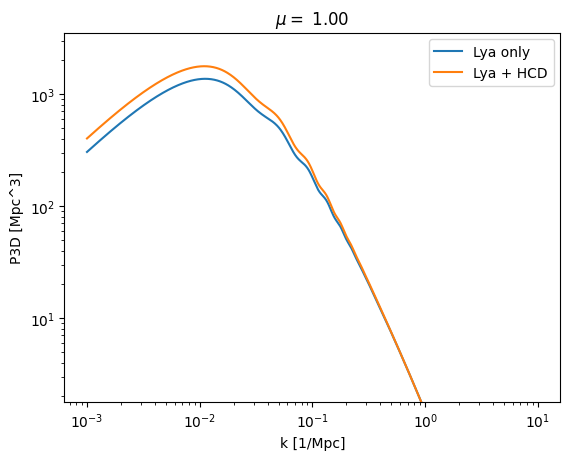

In [11]:
compare_p3d(mu=1.0, relative=False)